17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Number of training reviews: 25000
Number of testing reviews: 25000

Example label: 1
Original length of first review: 218
First 20 tokens: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
Negative training reviews: 12500
Positive training reviews: 12500
Training shape: (25000, 250)
Testing shape: (25000, 250)

First padded review:
[   1   14   22   16   43  530  973 1622 1385   65  458 4468   66 3941
    4  173   36  256    5   25  100   43  838  112   50  670    2    9
   35  480  284    5  150    4  172  112  167    2  336  385   39    4
  172 4536 1111   17  546   38   13  447    4  192   50   16    6  147
 2025   19   14   22    4 1920 4613  469    4   22   71   87   12   16
   43  530   38   76   15   13 1247    4   22   17  515   17   12   16
  626   18    2    5   62  386   12    8  316    8  106    5    4 2223
 5244   16  480   66 3785   33    4  130   12   16   38  619    5   25
  124 

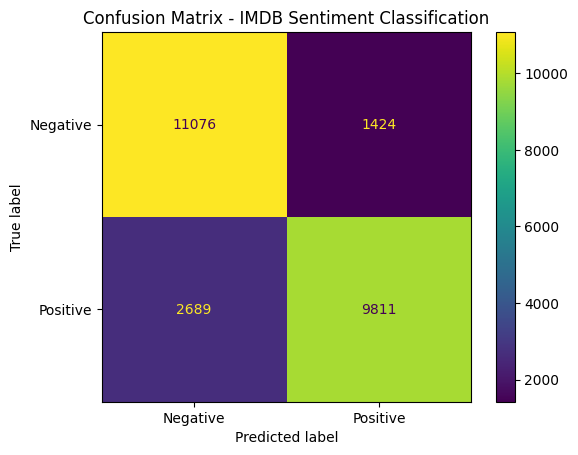

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from tensorflow.keras.datasets import imdb

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    ConfusionMatrixDisplay
)

np.random.seed(42)
torch.manual_seed(42)


VOCAB_SIZE = 10000
MAX_LEN = 250

(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE
)

print("Number of training reviews:", len(x_train))
print("Number of testing reviews:", len(x_test))

print("\nExample label:", y_train[0])
print("Original length of first review:", len(x_train[0]))
print("First 20 tokens:", x_train[0][:20])

# Labels:
# 0 = Negative review
# 1 = Positive review

print("Negative training reviews:", np.sum(y_train == 0))
print("Positive training reviews:", np.sum(y_train == 1))

def pad_sequences_pytorch(sequences, max_len=250):
    """
    Truncate reviews longer than max_len and
    pad shorter reviews with zeros.
    """

    padded = np.zeros(
        (len(sequences), max_len),
        dtype=np.int64
    )

    lengths = np.zeros(len(sequences), dtype=np.int64)

    for i, sequence in enumerate(sequences):

        # Truncate long reviews
        sequence = sequence[:max_len]

        # Actual sequence length
        length = len(sequence)
        lengths[i] = length

        # Post-padding
        padded[i, :length] = sequence

    return padded, lengths


x_train_pad, train_lengths = pad_sequences_pytorch(
    x_train,
    MAX_LEN
)

x_test_pad, test_lengths = pad_sequences_pytorch(
    x_test,
    MAX_LEN
)

print("Training shape:", x_train_pad.shape)
print("Testing shape:", x_test_pad.shape)

print("\nFirst padded review:")
print(x_train_pad[0])


indices = np.arange(len(x_train_pad))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

X_train = torch.tensor(
    x_train_pad[train_idx],
    dtype=torch.long
)

L_train = torch.tensor(
    train_lengths[train_idx],
    dtype=torch.long
)

Y_train = torch.tensor(
    y_train[train_idx],
    dtype=torch.float32
)

X_val = torch.tensor(
    x_train_pad[val_idx],
    dtype=torch.long
)

L_val = torch.tensor(
    train_lengths[val_idx],
    dtype=torch.long
)

Y_val = torch.tensor(
    y_train[val_idx],
    dtype=torch.float32
)

X_test = torch.tensor(
    x_test_pad,
    dtype=torch.long
)

L_test = torch.tensor(
    test_lengths,
    dtype=torch.long
)

Y_test = torch.tensor(
    y_test,
    dtype=torch.float32
)


train_dataset = TensorDataset(
    X_train,
    L_train,
    Y_train
)

val_dataset = TensorDataset(
    X_val,
    L_val,
    Y_val
)

test_dataset = TensorDataset(
    X_test,
    L_test,
    Y_test
)


BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Testing samples:", len(test_dataset))


class SentimentLSTM(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim=128,
        hidden_dim=128,
        num_layers=1,
        dropout=0.3
    ):

        super(SentimentLSTM, self).__init__()

        # Convert integer word IDs into dense vectors
        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

        # LSTM layer
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        self.dropout = nn.Dropout(dropout)

        # Final binary classifier
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x, lengths):

        # x:
        # [batch_size, sequence_length]

        embedded = self.embedding(x)

        # embedded:
        # [batch_size, sequence_length, embedding_dim]

        output, (hidden, cell) = self.lstm(embedded)

        # Get the output corresponding to the
        # final real word rather than padded positions
        batch_indices = torch.arange(
            x.size(0),
            device=x.device
        )

        last_output = output[
            batch_indices,
            lengths - 1
        ]

        last_output = self.dropout(last_output)

        logits = self.fc(last_output)

        return logits.squeeze(1)



model = SentimentLSTM(
    vocab_size=VOCAB_SIZE,
    embedding_dim=128,
    hidden_dim=128,
    dropout=0.3
)



print(model)


criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


def evaluate_model(model, data_loader, criterion):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for sequences, lengths, labels in data_loader:

            sequences = sequences
            lengths = lengths
            labels = labels

            logits = model(sequences, lengths)

            loss = criterion(logits, labels)

            total_loss += loss.item()

            probabilities = torch.sigmoid(logits)

            predictions = (
                probabilities >= 0.5
            ).float()

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    average_loss = total_loss / len(data_loader)

    accuracy = correct / total

    return average_loss, accuracy


EPOCHS = 8

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for sequences, lengths, labels in train_loader:

        sequences = sequences
        lengths = lengths
        labels = labels

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        logits = model(
            sequences,
            lengths
        )

        # Calculate loss
        loss = criterion(
            logits,
            labels
        )

        # Backpropagation
        loss.backward()

        # Prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5
        )

        optimizer.step()

        running_loss += loss.item()

        probabilities = torch.sigmoid(logits)

        predictions = (
            probabilities >= 0.5
        ).float()

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct / total

    val_loss, val_accuracy = evaluate_model(
        model,
        val_loader,
        criterion,
    )

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f} | "
        f"Validation Loss: {val_loss:.4f} | "
        f"Validation Accuracy: {val_accuracy:.4f}"
    )



model.eval()

all_labels = []
all_predictions = []
all_probabilities = []

with torch.no_grad():

    for sequences, lengths, labels in test_loader:

        sequences = sequences
        lengths = lengths

        logits = model(
            sequences,
            lengths
        )

        probabilities = torch.sigmoid(logits)

        predictions = (
            probabilities >= 0.5
        ).long()

        all_labels.extend(
            labels.numpy().astype(int)
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

all_labels = np.array(all_labels)

all_predictions = np.array(
    all_predictions
)

all_probabilities = np.array(
    all_probabilities
)




accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(f"Test Accuracy: {accuracy:.4f}")



print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=[
            "Negative",
            "Positive"
        ],
        digits=4
    )
)



cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("Confusion Matrix:")
print(cm)


tn, fp, fn, tp = cm.ravel()

print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Negative",
        "Positive"
    ]
)

disp.plot(
    values_format="d"
)

plt.title(
    "Confusion Matrix - IMDB Sentiment Classification"
)

plt.show()

